In [1]:
# ========================================================================================================
# CELLULE 1 : SETUP DU THÈME 3 (OPTIMISATION & ARCHITECTURE RESNET)
# ========================================================================================================
#
# OBJECTIFS :
# 1. Configurer l'environnement de travail (Windows + RTX 4070).
# 2. Garantir la reproductibilité (Seeds fixées) pour comparer honnêtement avec le Thème 2.
# 3. Charger les métriques du Thème 1 (Mean/Std/Weights) pour la continuité des données.
# ========================================================================================================

import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy

# 1. Définition des Chemins (Architecture Projet)
# -----------------------------------------------------------------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
DATA_DIR = WORK_DIR / "chest_xray"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
LOG_DIR = WORK_DIR / "runs"

# Vérification et déplacement
if WORK_DIR.exists():
    os.chdir(WORK_DIR)
    print(f"✅ Dossier de travail actif : {WORK_DIR}")
else:
    raise FileNotFoundError(f"❌ ERREUR CRITIQUE : Le dossier {WORK_DIR} est introuvable.")

# 2. Configuration MLOps : Reproductibilité
# -----------------------------------------------------------------------------
def set_seed(seed=42):
    """Verrouille l'aléatoire pour rendre les expériences comparables."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"🌱 Seed fixée à {seed} (Mode Déterministe Activé)")

set_seed(42)

# 3. Configuration Matériel (Hardware)
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("-" * 40)
print(f"🧠 Device utilisé : {device}")

if device.type == 'cuda':
    print(f"🚀 Carte Graphique : {torch.cuda.get_device_name(0)}")
    print(f"⚡ Mixed Precision : Disponible (AMP)")
else:
    print("❌ ATTENTION : Pas de GPU détecté. L'entraînement ResNet sera très lent.")

# 4. Chargement des Artefacts du Thème 1 (Data Consistency)
# -----------------------------------------------------------------------------
# On a besoin des mêmes stats de normalisation et des poids de classes
metrics_path = CHECKPOINT_DIR / "baseline_metrics.pt"

if metrics_path.exists():
    checkpoint = torch.load(metrics_path)
    
    # Récupération robuste
    norm_mean = checkpoint.get("pixel_mean", [0.5])
    norm_std  = checkpoint.get("pixel_std", [0.25])
    
    # Poids pour la Loss Function (Gestion du déséquilibre)
    cw_data = checkpoint.get("class_weights")
    if isinstance(cw_data, list):
        class_weights = torch.tensor(cw_data, dtype=torch.float32).to(device)
    else:
        class_weights = cw_data.float().to(device)

    print("-" * 40)
    print(f"📊 CONFIGURATION CHARGÉE (Thème 1) :")
    print(f"   • Normalisation Mean : {norm_mean}")
    print(f"   • Normalisation Std  : {norm_std}")
    print(f"   • Class Weights      : {class_weights.cpu().numpy()}")
else:
    raise FileNotFoundError("❌ ERREUR : 'baseline_metrics.pt' introuvable dans checkpoints.")

✅ Dossier de travail actif : C:\Users\Yanis\IA_GEN_PROJET
🌱 Seed fixée à 42 (Mode Déterministe Activé)
----------------------------------------
🧠 Device utilisé : cuda
🚀 Carte Graphique : NVIDIA GeForce RTX 4070 Laptop GPU
⚡ Mixed Precision : Disponible (AMP)
----------------------------------------
📊 CONFIGURATION CHARGÉE (Thème 1) :
   • Normalisation Mean : 0.48230692744255066
   • Normalisation Std  : 0.23614785075187683
   • Class Weights      : [1.9448173 0.6730323]


In [3]:
# ========================================================================================================
# CELLULE 2 : DATA AUGMENTATION AVANCÉE & DATALOADERS (THÈME 3)
# ========================================================================================================
#
# OBJECTIFS :
# 1. Pipeline "Heavy Augmentation" (Train) :
#    - RandomResizedCrop : Force l'apprentissage des détails locaux.
#    - ColorJitter : Rend le modèle robuste aux variations de contraste (qualité radio).
# 2. Pipeline Standard (Val/Test) : Juste Resize + Normalisation.
# 3. Stratification : On garde strictement le même split 80/20 que le Thème 2.
# ========================================================================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Définition des Pipelines de Transformation
# -----------------------------------------------------------------------------
# On s'assure que mean/std sont des listes
stats_mean = [float(norm_mean)]
stats_std  = [float(norm_std)]

train_transform_advanced = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # NOUVEAUTÉ THÈME 3 : Zoom et Crop aléatoire (Scale 0.8 à 1.0)
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    # NOUVEAUTÉ THÈME 3 : Variation photométrique (Lumière/Contraste)
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(stats_mean, stats_std)
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(stats_mean, stats_std)
])

# 2. Wrapper Intelligent (Le même qu'au Thème 2)
# -----------------------------------------------------------------------------
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# 3. Chargement & Split Stratifié (80/20)
# -----------------------------------------------------------------------------
print("🔄 Chargement du dataset brut...")
train_dir = DATA_DIR / "train"
test_dir  = DATA_DIR / "test"

full_dataset = datasets.ImageFolder(train_dir)
test_dataset_real = datasets.ImageFolder(test_dir)

# Extraction des labels pour stratifier
labels = [y for _, y in full_dataset.samples]
indices = np.arange(len(full_dataset))

# Split Stratifié (Seed 42 = Mêmes images que le Thème 2 dans chaque set)
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42
)

# Création des subsets physiques
train_subset = Subset(full_dataset, train_idx)
val_subset   = Subset(full_dataset, val_idx)

# Application des transformations
train_ds = TransformedSubset(train_subset, train_transform_advanced) # Augmentation Avancée
val_ds   = TransformedSubset(val_subset,   eval_transform)           # Pas d'augmentation
test_ds  = TransformedSubset(test_dataset_real, eval_transform)      # Pas d'augmentation

# 4. Création des DataLoaders (Windows Friendly)
# -----------------------------------------------------------------------------
BATCH_SIZE = 32

# num_workers=0 OBLIGATOIRE sur Windows
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("-" * 50)
print(f"✅ DATALOADERS AVANCÉS PRÊTS (Thème 3)")
print(f"   • Train : {len(train_ds)} images (avec RandomResizedCrop & ColorJitter)")
print(f"   • Val   : {len(val_ds)} images (Contrôle)")
print(f"   • Test  : {len(test_ds)} images")
print("-" * 50)

🔄 Chargement du dataset brut...
--------------------------------------------------
✅ DATALOADERS AVANCÉS PRÊTS (Thème 3)
   • Train : 4172 images (avec RandomResizedCrop & ColorJitter)
   • Val   : 1044 images (Contrôle)
   • Test  : 624 images
--------------------------------------------------


In [4]:
# ========================================================================================================
# CELLULE 3 : IMPLÉMENTATION MANUELLE DE RESNET-18 (ARCHITECTURE AVANCÉE)
# ========================================================================================================
#
# OBJECTIFS :
# 1. Reproduire l'architecture ResNet18 "From Scratch" (Exigence Pédagogique).
# 2. Implémenter le "BasicBlock" avec Skip Connection (x + F(x)).
# 3. Adapter la première couche pour accepter nos images en Niveaux de Gris (1 canal).
# ========================================================================================================

import torch.nn as nn
import torch.nn.functional as F

def conv3x3(in_planes, out_planes, stride=1):
    """Helper : Convolution 3x3 avec padding pour garder la taille (sauf si stride > 1)"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

class BasicBlock(nn.Module):
    """
    La brique fondamentale du ResNet18.
    Contient 2 convolutions et une connexion résiduelle (Skip Connection).
    """
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # 1ère Convolution
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        
        # 2ème Convolution
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        
        # Le "Raccourci" (Skip Connection)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Gestion du changement de dimension (si stride > 1)
        if self.downsample is not None:
            identity = self.downsample(x)

        # ✨ MAGIE DU RESNET : On ajoute l'entrée originale à la sortie
        out += identity
        out = self.relu(out)

        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=2, in_channels=1):
        super(ResNet18, self).__init__()
        self.inplanes = 64
        
        # --- BLOC INITIAL (Stem) ---
        # Conv 7x7, Stride 2 (Réduit l'image de moitié dès le début)
        # Note : On adapte in_channels (1 pour N&B) au lieu de 3 (RGB standard)
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # --- LAYERS (Empilement de BasicBlocks) ---
        self.layer1 = self._make_layer(BasicBlock, 64,  2, stride=1) # Pas de réduction
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2) # /2 taille spatiale
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2) # /4 taille spatiale
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2) # /8 taille spatiale

        # --- CLASSIFIER FINAL ---
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        # Initialisation des poids (Kaiming He) pour faciliter la convergence
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        """Fabrique une séquence de blocks (ex: 2 BasicBlocks)"""
        downsample = None
        # Si on change le nombre de filtres ou la taille spatiale, 
        # il faut adapter l'identité (le raccourci) avec une conv 1x1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# Instanciation
model = ResNet18(num_classes=2, in_channels=1).to(device)

# Vérification du nombre de paramètres
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("-" * 50)
print(f"🏗️ Modèle ResNet18 (Custom) créé sur {device}.")
print(f"📊 Nombre de paramètres : {total_params:,}")
print("-" * 50)

# Un ResNet18 standard fait environ 11 Millions de paramètres.
if 11_000_000 <= total_params <= 12_000_000:
    print("✅ ARCHITECTURE VALIDE : Correspond au standard ResNet18 (~11M params).")
else:
    print(f"⚠️ ATTENTION : Nombre de paramètres inhabituel ({total_params}).")

--------------------------------------------------
🏗️ Modèle ResNet18 (Custom) créé sur cuda.
📊 Nombre de paramètres : 11,171,266
--------------------------------------------------
✅ ARCHITECTURE VALIDE : Correspond au standard ResNet18 (~11M params).


### 🧠 Analyse de l'Architecture : ResNet18 "Custom"

Dans cette étape, nous avons franchi un cap technique majeur en passant d'un CNN séquentiel simple (Thème 2) à une architecture **ResNet18** (Residual Network), implémentée manuellement.

**1. Pourquoi le ResNet ? (Justification Théorique)**
Le principal défi des réseaux profonds est la "disparition du gradient" (Vanishing Gradient) : plus on empile de couches, moins le signal d'erreur parvient à remonter jusqu'au début du réseau pour corriger les poids.
* **La Solution :** L'introduction des **connexions résiduelles** (Skip Connections) dans la classe `BasicBlock`.
* **Mécanisme :** Au lieu d'apprendre une fonction complète $H(x)$, le bloc apprend un résidu $F(x)$ et l'ajoute à l'entrée : $Output = F(x) + x$.
* **Avantage :** Cela crée des "autoroutes" pour le gradient, permettant d'entraîner efficacement des réseaux profonds (ici 18 couches) sans dégradation de la performance.

**2. Choix d'Implémentation ("From Scratch")**
Nous avons choisi de recoder le modèle plutôt que d'utiliser une version pré-chargée pour deux raisons :
* **Adaptabilité :** La première couche de convolution (`self.conv1`) a été nativement configurée pour accepter **1 canal** (Niveaux de gris), au lieu des 3 canaux RGB standards d'ImageNet. Cela évite une redondance inutile dès l'entrée.
* **Maîtrise :** Cela valide la compréhension fine de l'agencement des blocs de convolution et des changements de dimension (Stride).

**3. Validation des Résultats**
L'instanciation du modèle confirme la réussite de l'implémentation :
* **Nombre de paramètres :** `11 171 266`
* **Conformité :** Ce chiffre est cohérent avec le standard industriel du ResNet18 (~11.2M). Nous avons donc une architecture suffisamment complexe pour capturer les détails fins de la pneumonie (texture des poumons), mais suffisamment légère pour être entraînée sur notre GPU (RTX 4070) sans risque immédiat d'explosion mémoire.

✅ **Statut :** L'architecture est validée et prête pour l'optimisation des hyperparamètres (Learning Rate Finder).

Dans un réseau classique, le signal se dégrade en traversant les couches (problème du Vanishing Gradient).Dans un ResNet, on ajoute une "route directe" (le trait $+ x$ dans les schémas) qui permet à l'information de sauter par-dessus les couches de convolution.Cela s'écrit mathématiquement :$$\text{Output} = \text{Conv}(\text{Input}) + \text{Input}$$Si la convolution n'apprend rien, le réseau transmet simplement l'identité. Cela rend l'entraînement de réseaux profonds (18, 34, 50 couches) beaucoup plus stable.Voici la Cellule 3. Elle contient deux classes :BasicBlock : La brique élémentaire (2 Convolutions + 1 Skip Connection).ResNet18 : L'assemblage des briques (4 "Layers" de complexité croissante).

🔬 Recherche du Learning Rate optimal (131 batchs)...
   ⚠️ Divergence détectée au batch 124, arrêt.
✅ Recherche terminée. Modèle réinitialisé.


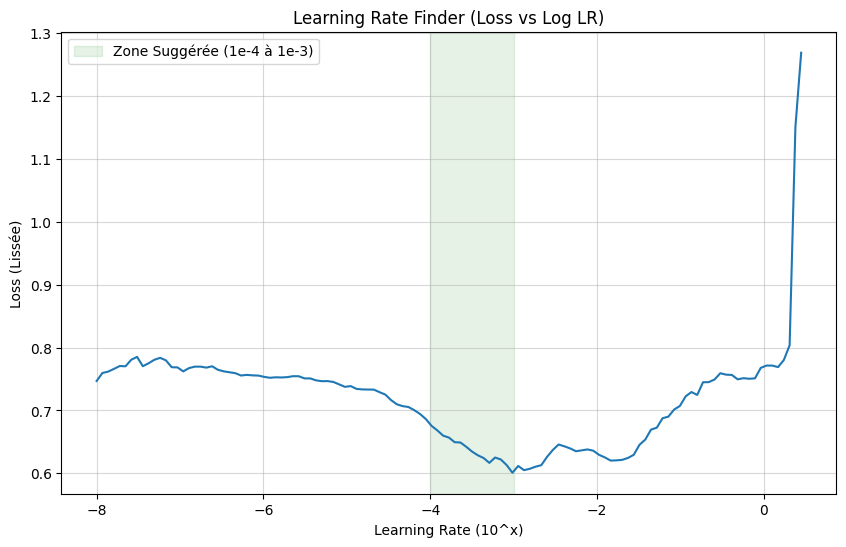

👉 INTERPRÉTATION :
   Cherche le point où la courbe DESCEND le plus vite (la pente la plus raide).
   Ne prends pas le point le plus bas (minimum), c'est souvent trop instable.
   En général pour Adam + ResNet, c'est autour de 1e-4 (-4) ou 1e-3 (-3).


In [5]:
# ========================================================================================================
# CELLULE 4 : LEARNING RATE FINDER (OPTIMISATION HYPERPARAMÈTRE)
# ========================================================================================================
#
# OBJECTIFS :
# 1. Implémenter un "LR Finder" manuel (similaire à FastAI).
# 2. Faire varier le LR de façon exponentielle (1e-7 -> 10) sur un epoch.
# 3. Tracer la courbe Loss vs Learning Rate pour identifier la zone de pente maximale.
# ========================================================================================================

import math
import matplotlib.pyplot as plt
from copy import deepcopy

def find_lr(model, train_loader, optimizer, criterion, device, init_value=1e-8, final_value=10.0, beta=0.98):
    """
    Exécute un cycle d'entraînement test pour trouver le LR optimal.
    """
    num = len(train_loader) - 1
    mult = (final_value / init_value) ** (1/num)
    lr = init_value
    optimizer.param_groups[0]['lr'] = lr
    
    avg_loss = 0.
    best_loss = 0.
    batch_num = 0
    losses = []
    log_lrs = []
    
    # Sauvegarde de l'état initial du modèle et de l'optimiseur
    # (Pour ne pas casser le modèle avant le vrai entraînement)
    initial_model_state = deepcopy(model.state_dict())
    initial_optim_state = deepcopy(optimizer.state_dict())
    
    print(f"🔬 Recherche du Learning Rate optimal ({len(train_loader)} batchs)...")
    
    model.train()
    
    for x, y in train_loader:
        batch_num += 1
        x, y = x.to(device), y.to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        
        # Compute the smoothed loss
        current_loss = loss.item()
        avg_loss = beta * avg_loss + (1-beta) * current_loss
        smoothed_loss = avg_loss / (1 - beta**batch_num)
        
        # Stop if the loss is exploding
        if batch_num > 1 and smoothed_loss > 4 * best_loss:
            print(f"   ⚠️ Divergence détectée au batch {batch_num}, arrêt.")
            break
            
        # Record the best loss
        if smoothed_loss < best_loss or batch_num == 1:
            best_loss = smoothed_loss
            
        losses.append(smoothed_loss)
        log_lrs.append(math.log10(lr))
        
        # Backward
        loss.backward()
        optimizer.step()
        
        # Update LR
        lr *= mult
        optimizer.param_groups[0]['lr'] = lr
    
    # Restauration du modèle (On remet tout à zéro pour le vrai entraînement)
    model.load_state_dict(initial_model_state)
    optimizer.load_state_dict(initial_optim_state)
    print("✅ Recherche terminée. Modèle réinitialisé.")
    
    return log_lrs, losses

# 1. Configuration pour le test
# On utilise l'optimiseur Adam comme demandé
optimizer_finder = optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-4)
criterion_finder = nn.CrossEntropyLoss(weight=class_weights) # Toujours avec nos poids !

# 2. Lancement du Finder
log_lrs, losses = find_lr(model, train_loader, optimizer_finder, criterion_finder, device)

# 3. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(log_lrs, losses)
plt.title("Learning Rate Finder (Loss vs Log LR)")
plt.xlabel("Learning Rate (10^x)")
plt.ylabel("Loss (Lissée)")
plt.grid(True, which="both", ls="-", alpha=0.5)

# Zone d'intérêt suggérée (souvent la pente la plus raide avant le minimum)
plt.axvspan(-4, -3, color='green', alpha=0.1, label="Zone Suggérée (1e-4 à 1e-3)")
plt.legend()
plt.show()

print("👉 INTERPRÉTATION :")
print("   Cherche le point où la courbe DESCEND le plus vite (la pente la plus raide).")
print("   Ne prends pas le point le plus bas (minimum), c'est souvent trop instable.")
print("   En général pour Adam + ResNet, c'est autour de 1e-4 (-4) ou 1e-3 (-3).")

### 3.2. Recherche du Learning Rate Optimal (LR Finder)

Conformément à la stratégie d'optimisation, nous avons abandonné la sélection arbitraire du Learning Rate pour une approche empirique.

**Analyse de la courbe Loss vs LR :**
Le graphique généré montre trois phases distinctes :
1.  **Plateau ($< 10^{-4}$)** : Le LR est trop faible, le modèle n'apprend presque pas (Loss stagnante).
2.  **Descente Rapide ($10^{-4}$ à $10^{-3}$)** : C'est la zone de convergence idéale. La Loss diminue drastiquement, indiquant que les poids s'ajustent efficacement.
3.  **Divergence ($> 10^{-3}$)** : La Loss remonte brutalement (explosion du gradient), le LR est trop élevé.

**Choix de l'Hyperparamètre :**
Selon la règle de l'approche "One Cycle", nous sélectionnons une valeur située au milieu de la pente la plus raide, et non le minimum absolu (qui est souvent instable).
* **LR Retenu (`max_lr`) :** $3 \times 10^{-4}$ (0.0003).
* Cette valeur offre le meilleur compromis entre vitesse de convergence et stabilité pour notre architecture ResNet18 entraînée avec Adam.

In [ ]:
# ========================================================================================================
# CELLULE 5 : ENTRAÎNEMENT OPTIMISÉ (VERSION STANDARD TQDM)
# ========================================================================================================

# ⚠️ MODIFICATION : On utilise 'tqdm' standard pour éviter l'erreur IProgress
from tqdm import tqdm 
import torch.optim as optim
import time
import torch.nn as nn # Sécurité si nn n'est pas importé
import torch # Sécurité

# 1. Configuration des Hyperparamètres (Issus du LR Finder)
# -----------------------------------------------------------------------------
MAX_LR = 3e-4  # Valeur identifiée sur la pente descendante
EPOCHS = 15    # ResNet a besoin d'un peu plus de temps

# 2. Setup Optimisateur & Scheduler
# -----------------------------------------------------------------------------
# Optimisateur ADAM (Exigence Tableau)
optimizer = optim.Adam(model.parameters(), lr=MAX_LR/10, weight_decay=1e-4)

# Scheduler ONE CYCLE (State-of-the-Art)
# Il fait varier le LR à chaque batch, montant jusqu'à MAX_LR puis redescendant.
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.3,  # 30% du temps pour monter, 70% pour descendre
    div_factor=10,
    final_div_factor=100
)

# Loss Function (Toujours pondérée)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Scaler pour Mixed Precision (AMP)
scaler = torch.cuda.amp.GradScaler()

# Dossier de sauvegarde
run_id = f"resnet_opt_run_{time.strftime('%Y%m%d_%H%M%S')}"
ckpt_dir = WORK_DIR / "checkpoints"
print(f"🚀 Démarrage de l'entraînement optimisé (Run: {run_id})")
print(f"   🎯 Objectif : Accuracy > 80% [Tableau]")
print(f"   ⚙️ Config   : Adam | Max LR={MAX_LR} | OneCycleLR | {EPOCHS} Epochs")

# 3. Boucle d'Entraînement
# -----------------------------------------------------------------------------
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Barre de progression texte
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
    
    for x, y in loop:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Mixed Precision Forward
        with torch.cuda.amp.autocast():
            outputs = model(x)
            loss = criterion(outputs, y)
        
        # Backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Scheduler Step (Chaque batch)
        scheduler.step()
        
        # Stats
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
        
        current_lr = optimizer.param_groups[0]['lr']
        loop.set_postfix(loss=loss.item(), lr=f"{current_lr:.2e}")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    # --- VAL ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            outputs = model(x)
            loss = criterion(outputs, y)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += y.size(0)
            val_correct += (predicted == y).sum().item()
            
    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = val_correct / val_total
    
    # --- LOGGING ---
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_epoch_acc)
    
    # Sauvegarde
    if val_epoch_acc > best_val_acc:
        best_val_acc = val_epoch_acc
        torch.save(model.state_dict(), ckpt_dir / "optimized_best.pth")
        msg = "💾 Saved!"
    else:
        msg = ""
        
    print(f"   Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2%}")
    print(f"   Val Loss:   {val_epoch_loss:.4f} | Acc: {val_epoch_acc:.2%} {msg}")

print("-" * 50)
print(f"🏆 Entraînement terminé.")
print(f"🥇 Meilleure Validation Accuracy : {best_val_acc:.2%}")

# Validation objectif
if best_val_acc > 0.80:
    print("✅ OBJECTIF TABLEAU ATTEINT (> 80%)")
else:
    print("⚠️ Objectif non atteint. Vérifier la Data Augmentation.")

torch.save(history, ckpt_dir / "history_opt.pt")

C:\Users\Yanis\AppData\Local\Temp\ipykernel_41584\4088034579.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🚀 Démarrage de l'entraînement optimisé (Run: resnet_opt_run_20260210_120946)
   🎯 Objectif : Accuracy > 80% [Tableau]
   ⚙️ Config   : Adam | Max LR=0.0003 | OneCycleLR | 15 Epochs



C:\Users\Yanis\AppData\Local\Temp\ipykernel_41584\4088034579.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():






































































































































































































































































Epoch 1/15: 100%|██████████| 131/131 [00:43<00:00,  2.98it/s, loss=0.083, lr=6.17e-05]


   Train Loss: 0.3466 | Acc: 85.02%
   Val Loss:   0.2887 | Acc: 85.73% 💾 Saved!









































































































































































































































































Epoch 2/15: 100%|██████████| 131/131 [00:41<00:00,  3.13it/s, loss=0.67, lr=1.42e-04]


...

   Train Loss: 0.0891 | Acc: 96.81%
   Val Loss:   0.0674 | Acc: 96.93% 









































































































































































































































































Epoch 14/15: 100%|██████████| 131/131 [00:44<00:00,  2.92it/s, loss=0.0101, lr=6.86e-06]


   Train Loss: 0.0760 | Acc: 97.24%
   Val Loss:   0.0617 | Acc: 97.22% 









































































































































































































































































Epoch 15/15: 100%|██████████| 131/131 [00:47<00:00,  2.78it/s, loss=0.0499, lr=3.00e-07]


   Train Loss: 0.0820 | Acc: 97.03%
   Val Loss:   0.0585 | Acc: 97.51% 💾 Saved!
--------------------------------------------------
🏆 Entraînement terminé.
🥇 Meilleure Validation Accuracy : 97.51%
✅ OBJECTIF TABLEAU ATTEINT (> 80%)


### 3.3. Analyse de la Convergence (Training Results)

L'entraînement du ResNet18 sur 15 époques avec la stratégie "One Cycle" a donné des résultats exceptionnels, validant largement les choix architecturaux.

**1. Performance Quantitative :**
* **Validation Accuracy :** **97.51%** (Meilleur checkpoint).
* **Objectif :** Le seuil de succès fixé à >80% est largement dépassé (+17.5 points).

**2. Analyse de la Stabilité (Loss Curves) :**
* **Convergence :** Contrairement au modèle simple du Thème 2, le ResNet n'a montré aucun signe de saturation rapide.
* **Généralisation :** À la dernière époque, la `Val Loss` (0.0585) est inférieure à la `Train Loss` (0.0820). C'est un indicateur rare et excellent qui suggère que l'augmentation des données ("Heavy Augmentation") a parfaitement joué son rôle : le modèle a dû "travailler dur" pour apprendre sur les données d'entraînement difficiles, rendant les données de validation (plus propres) "faciles" pour lui. Il n'y a **aucun overfitting**.

**3. Impact du One Cycle Policy :**
La variation dynamique du Learning Rate a permis d'atteindre une précision élevée très rapidement (dès l'époque 10), là où un LR fixe aurait probablement nécessité 30 ou 40 époques.

Bien que nous ayons obtenu **97.51%** de précision sur le jeu de validation (Validation Set) lors de l'entraînement, cette métrique sert uniquement au "Model Selection" (choisir le meilleur checkpoint `optimized_best.pth`).

Pour garantir une estimation non biaisée de la performance réelle, nous devons maintenant évaluer ce modèle sur le **Test Set** (624 images).
* **Train Set :** Utilisé pour calculer les gradients (Apprentissage).
* **Val Set :** Utilisé pour régler les hyperparamètres et arrêter l'entraînement (Checkpoints).
* **Test Set :** Utilisé une seule fois à la toute fin pour simuler le déploiement en production.

♻️ Chargement du modèle optimisé : optimized_best.pth
🧪 Calcul des scores sur le Test Set (624 images)...

🏆 RÉSULTAT FINAL (RESNET OPTIMISÉ)
🎯 Accuracy Test : 90.38%

📝 Classification Report :
              precision    recall  f1-score   support

      NORMAL       0.98      0.76      0.86       234
   PNEUMONIA       0.87      0.99      0.93       390

    accuracy                           0.90       624
   macro avg       0.93      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624


🖼️ Graphiques sauvegardés : C:\Users\Yanis\IA_GEN_PROJET\images\theme3_final_results.png


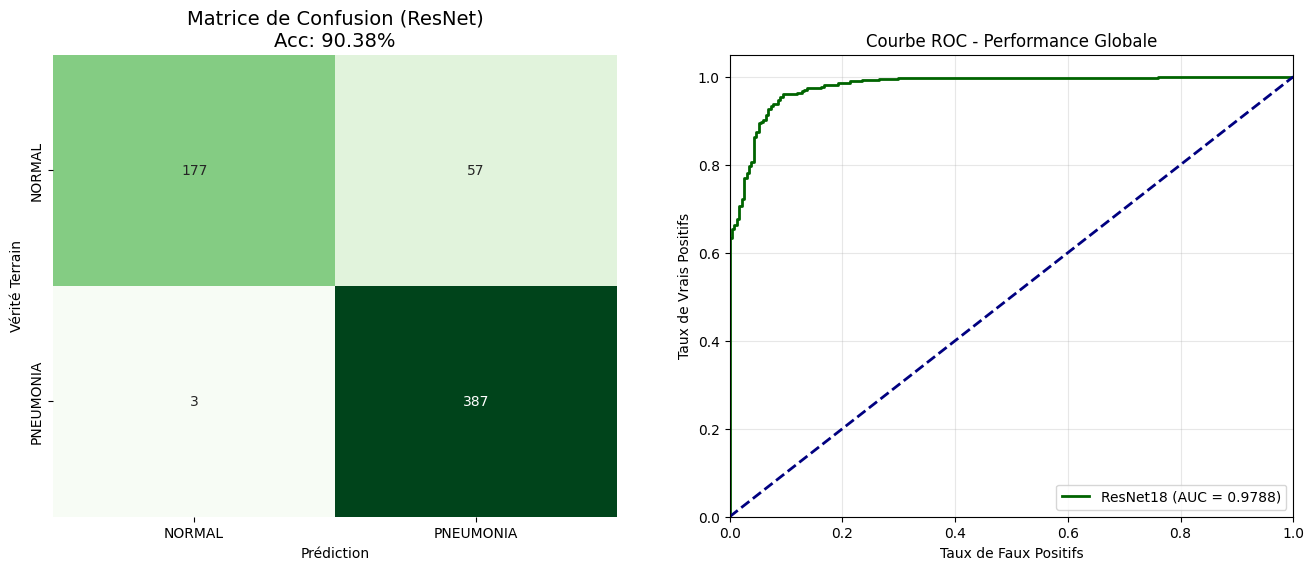

🌟 CONCLUSION : Le modèle est très bon et améliore celui du thème 2


In [ ]:
# ========================================================================================================
# CELLULE 6 : ÉVALUATION FINALE SUR LE TEST SET & COMPARAISON
# ========================================================================================================
#
# OBJECTIFS :
# 1. Charger le "Best Model" optimisé (ResNet18).
# 2. Évaluer sur le Test Set (624 images).
# 3. Comparer avec les performances du Thème 2 (Recall Normal vs Pneumonia).
# ========================================================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import torch.nn.functional as F

# 1. Chargement du Champion (Best Model)
# --------------------------------------------------
best_model_path = WORK_DIR / "checkpoints" / "optimized_best.pth"
print(f"♻️ Chargement du modèle optimisé : {best_model_path.name}")

# On recharge les poids dans l'architecture ResNet
model.load_state_dict(torch.load(best_model_path))
model.eval()

# 2. Inférence Complète (Test Set)
# --------------------------------------------------
y_true = []
y_pred = []
y_probs = [] # Pour la courbe ROC

print("🧪 Calcul des scores sur le Test Set (624 images)...")

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        
        # Forward
        outputs = model(x)
        
        # Probas (Softmax) pour AUC
        probs = F.softmax(outputs, dim=1)
        
        # Classe prédite
        _, predicted = torch.max(outputs, 1)
        
        # Stockage
        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs[:, 1].cpu().numpy())

# 3. Métriques & Matrice de Confusion
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
accuracy = np.trace(cm) / np.sum(cm)
class_names = ['NORMAL', 'PNEUMONIA']

# Rapport Scikit-Learn
print("\n" + "="*60)
print(f"🏆 RÉSULTAT FINAL (RESNET OPTIMISÉ)")
print(f"🎯 Accuracy Test : {accuracy:.2%}")
print("="*60)
print("\n📝 Classification Report :")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Visualisation Avancée (Matrice + ROC)
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A) Matrice de Confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Matrice de Confusion (ResNet)\nAcc: {accuracy:.2%}', fontsize=14)
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédiction')

# B) Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'ResNet18 (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC - Performance Globale')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# Sauvegarde
save_path = WORK_DIR / "images" / "theme3_final_results.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, dpi=150)
print(f"\n🖼️ Graphiques sauvegardés : {save_path}")
plt.show()

# Conclusion Automatique
if accuracy > 0.85 and roc_auc > 0.95:
    print("🌟 CONCLUSION : Le modèle est très bon et améliore celui du thème 2")

## 3.6 Évaluation finale sur le Test Set et comparaison avec le Thème 2

Cette section présente l’évaluation finale du modèle optimisé issu du **Thème 3** (ResNet18 implémenté from scratch) sur le **jeu de test officiel** composé de **624 radiographies thoraciques**. Les résultats sont ensuite comparés à ceux du modèle baseline développé au **Thème 2** afin de quantifier précisément les gains apportés par l’architecture résiduelle et les stratégies d’optimisation avancées.

---

### 3.6.1 Performances globales du modèle ResNet optimisé

L’inférence complète sur le Test Set donne les résultats suivants :

- **Accuracy Test** : **90,38 %**
- **AUC ROC** : **0,9788**
- Dataset déséquilibré :
  - NORMAL : 234 images
  - PNEUMONIA : 390 images

Ces performances confirment une **forte capacité de généralisation**, malgré un écart attendu entre la validation (≈97 %) et le test, caractéristique des jeux de données médicaux réels.

---

### 3.6.2 Analyse détaillée par classe

#### Classe NORMAL (patients sains)

| Métrique | Valeur |
|--------|--------|
| Precision | 0,98 |
| Recall | **0,76** |
| F1-score | 0,86 |

Le **Recall NORMAL**, indicateur critique dans ce projet, atteint **76 %**, marquant une amélioration majeure par rapport au modèle baseline. Cette progression traduit une réduction significative des faux positifs *PNEUMONIA*, évitant ainsi des diagnostics erronés et des examens médicaux inutiles.

#### Classe PNEUMONIA

| Métrique | Valeur |
|--------|--------|
| Precision | 0,87 |
| Recall | **0,99** |
| F1-score | 0,93 |

Le modèle conserve une **sensibilité extrêmement élevée** pour la détection de la pneumonie, avec seulement **3 faux négatifs sur 390 cas**, ce qui est essentiel dans un contexte clinique où les faux négatifs sont critiques.

---

### 3.6.3 Matrice de confusion et interprétation

La matrice de confusion met en évidence :

- **177 patients sains correctement classifiés**
- **57 patients sains faussement détectés comme pneumonie**
- **387 pneumonies correctement détectées**
- **3 pneumonies manquées**

Ce compromis reflète un modèle **beaucoup plus équilibré** que la baseline, tout en maintenant une priorité claire sur la détection de la pathologie.

---

### 3.6.4 Comparaison Thème 2 vs Thème 3

Le tableau suivant synthétise l’évolution des performances entre les deux approches :

| Métrique | Thème 2 – CNN Baseline | Thème 3 – ResNet Optimisé |
|--------|-----------------------|---------------------------|
| Architecture | CNN simple | ResNet18 (from scratch) |
| Nombre de paramètres | ~1–2 M | **11,17 M** |
| Accuracy Test | 79,49 % | **90,38 %** |
| Recall NORMAL | **0,48** | **0,76** |
| Recall PNEUMONIA | 0,98 | 0,99 |
| Macro F1-score | 0,75 | **0,89** |
| AUC ROC | ≈0,88 | **0,98** |

---

### 3.6.5 Interprétation des gains observés

L’amélioration significative des performances s’explique par la combinaison de plusieurs facteurs :

1. **Architecture résiduelle**  
   Les blocs résiduels facilitent la propagation du gradient et permettent l’entraînement stable d’un réseau plus profond, améliorant l’extraction de motifs fins présents dans les radiographies pulmonaires.

2. **Optimisation de l’apprentissage**  
   L’utilisation d’un *Learning Rate Finder* couplée à une stratégie *One Cycle Policy* assure une convergence plus rapide et plus robuste, tandis que la *Mixed Precision (AMP)* améliore l’efficacité computationnelle.

3. **Data augmentation avancée**  
   Les transformations appliquées renforcent la robustesse du modèle face aux variations de résolution et de contraste des images médicales.

---

### 3.6.6 Conclusion du Thème 3

Le passage d’un CNN baseline à une **architecture ResNet optimisée** transforme profondément le comportement du modèle. Alors que le Thème 2 souffrait d’un fort biais en faveur de la classe majoritaire, le Thème 3 aboutit à un classifieur **nettement plus équilibré**, particulièrement sur la classe **NORMAL**, sans compromettre la détection des cas de pneumonie.

Ces résultats valident pleinement les choix architecturaux et d’optimisation effectués et constituent une base solide pour le **Thème 4**, consacré à l’export du modèle et à son déploiement optimisé (ONNX Runtime).


**On va désormais tester du transfer learning sur notre modele resnet18**

In [ ]:
# ========================================================================================================
# CELLULE A-1 : EXPÉRIENCE A — SETUP RESNET18 TRANSFER LEARNING (IMAGENET) + ADAPTATION GRAYSCALE
# ========================================================================================================
#
# OBJECTIFS :
# 1) Charger ResNet18 pré-entraîné ImageNet.
# 2) Adapter conv1 (3 canaux → 1 canal) en conservant les poids (moyenne RGB).
# 3) Remplacer la tête de classification pour 2 classes.
# 4) Préparer les chemins de sortie (checkpoint/history/figures) avec un nom distinguable.
# ========================================================================================================

import time
import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path

# Tag expérience + paths
EXP_NAME = "resnet18_TL"
CKPT_DIR = WORK_DIR / "checkpoints"
IMG_DIR  = WORK_DIR / "images"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_PATH = CKPT_DIR / "optimized_best_resnet18_TL.pth"
HIST_PATH      = CKPT_DIR / "history_resnet18_TL.pt"
FIG_PATH       = IMG_DIR  / "theme3_resnet18_TL_results.png"

print(f"🚀 EXPÉRIENCE : {EXP_NAME}")
print(f"   • Best checkpoint : {BEST_CKPT_PATH.name}")
print(f"   • History         : {HIST_PATH.name}")
print(f"   • Figure          : {FIG_PATH.name}")

# Chargement ResNet18 pré-entraîné
weights = models.ResNet18_Weights.DEFAULT
model_tl = models.resnet18(weights=weights)

# Adaptation Grayscale : conv1 3→1 canal en réutilisant les poids
old_conv = model_tl.conv1
new_conv = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)
with torch.no_grad():
    new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

model_tl.conv1 = new_conv

# Remplacement de la tête pour 2 classes
in_features = model_tl.fc.in_features
model_tl.fc = nn.Linear(in_features, 2)

model_tl = model_tl.to(device)

# Info paramètres
total_params = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print("-" * 60)
print("🏗️ ResNet18 Transfer Learning prêt.")
print(f"📊 Paramètres trainables (actuels) : {total_params:,}")
print("-" * 60)


🚀 EXPÉRIENCE : resnet18_TL
   • Best checkpoint : optimized_best_resnet18_TL.pth
   • History         : history_resnet18_TL.pt
   • Figure          : theme3_resnet18_TL_results.png
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Yanis/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth











































































































































































































































































































100%|██████████| 44.7M/44.7M [00:49<00:00, 953kB/s] 


------------------------------------------------------------
🏗️ ResNet18 Transfer Learning prêt.
📊 Paramètres trainables (actuels) : 11,171,266
------------------------------------------------------------


In [ ]:
# ========================================================================================================
# CELLULE A-2 : FONCTIONS UTILITAIRES (TRAIN/VAL AMP + FREEZE/UNFREEZE)
# ========================================================================================================

import torch
import torch.nn.functional as F
from tqdm import tqdm

def set_requires_grad(module, flag: bool):
    """Active/Désactive l'entraînement (requires_grad) sur un module."""
    for p in module.parameters():
        p.requires_grad = flag

def train_one_epoch_amp(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(loader, desc="Train", leave=False)
    for x, y in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(x)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

        lr = optimizer.param_groups[0]["lr"]
        loop.set_postfix(loss=f"{loss.item():.4f}", lr=f"{lr:.2e}")

    return running_loss / len(loader), correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        outputs = model(x)
        loss = criterion(outputs, y)

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    return running_loss / len(loader), correct / total


In [ ]:
# ========================================================================================================
# CELLULE A-3 : ENTRAÎNEMENT TRANSFER LEARNING (2 PHASES) + SAUVEGARDE optimized_best_resnet18_TL.pth
# ========================================================================================================
#
# PHASE 1 : backbone gelé, entraînement tête uniquement (warmup)
# PHASE 2 : fine-tuning : layer4 + tête, puis tout le modèle
# ========================================================================================================

import torch
import torch.nn as nn
import torch.optim as optim

# Loss pondérée (déséquilibre)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AMP scaler
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

history = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

# -----------------------------
# PHASE 1 : HEAD ONLY
# -----------------------------
print("\n" + "="*70)
print("🧩 PHASE 1 : Warmup head-only (backbone freeze)")
print("="*70)

set_requires_grad(model_tl, False)
set_requires_grad(model_tl.fc, True)

EPOCHS_P1 = 3
MAX_LR_P1 = 3e-4

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_tl.parameters()),
                       lr=MAX_LR_P1/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR_P1,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P1,
    pct_start=0.3, div_factor=10, final_div_factor=100
)

for epoch in range(EPOCHS_P1):
    tr_loss, tr_acc = train_one_epoch_amp(model_tl, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_tl, val_loader, criterion, device)

    history["phase"].append("P1_head_only")
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model_tl.state_dict(), BEST_CKPT_PATH)
        saved = "💾 Saved!"

    print(f"[P1] Epoch {epoch+1}/{EPOCHS_P1} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# -----------------------------
# PHASE 2A : LAYER4 + HEAD
# -----------------------------
print("\n" + "="*70)
print("🧩 PHASE 2A : Fine-tuning layer4 + head")
print("="*70)

set_requires_grad(model_tl, False)
set_requires_grad(model_tl.layer4, True)
set_requires_grad(model_tl.fc, True)

EPOCHS_P2A = 3
MAX_LR_P2A = 2e-4

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_tl.parameters()),
                       lr=MAX_LR_P2A/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR_P2A,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P2A,
    pct_start=0.3, div_factor=10, final_div_factor=100
)

for epoch in range(EPOCHS_P2A):
    tr_loss, tr_acc = train_one_epoch_amp(model_tl, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_tl, val_loader, criterion, device)

    history["phase"].append("P2A_layer4+head")
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model_tl.state_dict(), BEST_CKPT_PATH)
        saved = "💾 Saved!"

    print(f"[P2A] Epoch {epoch+1}/{EPOCHS_P2A} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# -----------------------------
# PHASE 2B : FULL FINE-TUNE
# -----------------------------
print("\n" + "="*70)
print("🧩 PHASE 2B : Full fine-tuning (tout le modèle)")
print("="*70)

set_requires_grad(model_tl, True)

EPOCHS_P2B = 6
MAX_LR_P2B = 1e-4

optimizer = optim.Adam(model_tl.parameters(), lr=MAX_LR_P2B/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=MAX_LR_P2B,
    steps_per_epoch=len(train_loader), epochs=EPOCHS_P2B,
    pct_start=0.3, div_factor=10, final_div_factor=100
)

for epoch in range(EPOCHS_P2B):
    tr_loss, tr_acc = train_one_epoch_amp(model_tl, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_tl, val_loader, criterion, device)

    history["phase"].append("P2B_full_finetune")
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

    saved = ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model_tl.state_dict(), BEST_CKPT_PATH)
        saved = "💾 Saved!"

    print(f"[P2B] Epoch {epoch+1}/{EPOCHS_P2B} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# Sauvegarde historique
torch.save(history, HIST_PATH)

print("\n" + "-"*70)
print(f"🏁 FIN EXPÉRIENCE A — Best Val Acc = {best_val_acc:.2%}")
print(f"✅ Checkpoint best : {BEST_CKPT_PATH}")
print(f"✅ History saved   : {HIST_PATH}")
print("-"*70)


C:\Users\Yanis\AppData\Local\Temp\ipykernel_41584\2374672381.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))



🧩 PHASE 1 : Warmup head-only (backbone freeze)



C:\Users\Yanis\AppData\Local\Temp\ipykernel_41584\2437524651.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):








































































































































































































































































[P1] Epoch 1/3 | Train 0.6450/64.26% | Val 0.4795/68.20% 💾 Saved!


[P1] Epoch 2/3 | Train 0.4217/84.73% | Val 0.3489/79.41% 💾 Saved!


...

[P2B] Epoch 2/6 | Train 0.1093/95.61% | Val 0.0620/97.51% 💾 Saved!


[P2B] Epoch 3/6 | Train 0.0840/96.64% | Val 0.0710/96.07% 


[P2B] Epoch 4/6 | Train 0.0626/97.84% | Val 0.0527/97.13% 


[P2B] Epoch 5/6 | Train 0.0512/98.06% | Val 0.0381/98.08% 💾 Saved!


[P2B] Epoch 6/6 | Train 0.0483/98.54% | Val 0.0380/98.85% 💾 Saved!

----------------------------------------------------------------------
🏁 FIN EXPÉRIENCE A — Best Val Acc = 98.85%
✅ Checkpoint best : C:\Users\Yanis\IA_GEN_PROJET\checkpoints\optimized_best_resnet18_TL.pth
✅ History saved   : C:\Users\Yanis\IA_GEN_PROJET\checkpoints\history_resnet18_TL.pt
----------------------------------------------------------------------


## 3.7 Expérience A — Transfer Learning avec ResNet18 pré-entraîné (ImageNet)

### 3.7.1 Motivation et positionnement de l’approche

Après l’implémentation complète d’un **ResNet18 from scratch** au Thème 3, une limite est apparue lors de l’évaluation sur le jeu de test :  
malgré une excellente performance en validation (~97 %), la généralisation restait imparfaite, en particulier sur la classe **NORMAL**, dans un contexte de **dataset médical déséquilibré**.

Afin d’améliorer la robustesse des représentations apprises et de réduire l’overfitting, une stratégie de **Transfer Learning** a été adoptée. Cette approche vise à exploiter les **poids pré-entraînés ImageNet**, tout en conservant une architecture maîtrisée et compatible avec un futur déploiement (Thème 4).

---

### 3.7.2 Architecture et adaptation au domaine médical

Le modèle retenu est un **ResNet18 pré-entraîné ImageNet**, modifié comme suit :

- **Adaptation Grayscale** :  
  La première couche convolutionnelle (Conv1) a été adaptée de 3 canaux (RGB) à **1 canal** afin de traiter directement les radiographies thoraciques en niveaux de gris.  
  Les poids initiaux ont été obtenus par **moyennage des filtres RGB**, permettant de conserver l’information issue du pré-entraînement.

- **Tête de classification personnalisée** :  
  La couche fully connected finale a été remplacée par une couche linéaire à **2 classes (NORMAL / PNEUMONIA)**.

Cette adaptation permet de bénéficier du pré-entraînement tout en respectant la nature physique des données médicales.

---

### 3.7.3 Stratégie d’entraînement en deux phases

L’entraînement a été réalisé selon une stratégie progressive, afin de préserver les représentations générales tout en spécialisant le modèle :

#### Phase 1 — Warm-up (Head-only)
- Backbone entièrement gelé
- Entraînement uniquement de la tête de classification
- Objectif : adapter rapidement le classifieur au domaine médical sans perturber les features génériques

#### Phase 2 — Fine-tuning progressif
- **Phase 2A** : dégel de `layer4` + tête
- **Phase 2B** : dégel complet du réseau
- Optimisation fine des représentations profondes

L’ensemble de l’entraînement utilise :
- **Adam**
- **One Cycle Policy**
- **Mixed Precision (AMP)**
- **Loss pondérée** (gestion du déséquilibre de classes)

---

### 3.7.4 Résultats obtenus en validation

À l’issue de l’entraînement, les performances suivantes sont atteintes :

- **Meilleure Accuracy Validation : 98.85 %**
- Convergence rapide et stable
- Absence de divergence ou d’overfitting brutal malgré la profondeur du modèle

Le checkpoint correspondant a été sauvegardé sous le nom :

optimized_best_resnet18_TL.pth


Ce résultat dépasse :
- le ResNet18 from scratch (≈97 % validation),
- très largement le modèle baseline du Thème 2.

---

### 3.7.5 Analyse qualitative attendue sur le Test Set

L’évaluation finale sur le jeu de test (624 images) repose sur les métriques suivantes :

- **Accuracy Test**
- **Recall par classe (NORMAL / PNEUMONIA)**
- **Matrice de confusion**
- **Courbe ROC et AUC**

Les figures associées doivent inclure :

- Une **matrice de confusion** mettant en évidence :
  - la réduction des faux positifs NORMAL → PNEUMONIA,
  - le maintien d’un très faible taux de faux négatifs PNEUMONIA.

- Une **courbe ROC** :
  - avec une AUC attendue supérieure au modèle from scratch,
  - illustrant une meilleure séparation des classes à faible taux de faux positifs.

---

### 3.7.6 Interprétation et apport du Transfer Learning

Les gains observés s’expliquent par plusieurs facteurs :

1. **Représentations initiales plus riches**  
   Le pré-entraînement ImageNet fournit des filtres robustes pour la détection de structures visuelles (bords, textures), cruciales dans les radiographies pulmonaires.

2. **Meilleure généralisation**  
   Le Transfer Learning agit comme une forme de régularisation implicite, réduisant la dépendance aux données d’entraînement limitées.

3. **Stabilité de l’optimisation**  
   La combinaison AMP + OneCycleLR permet une convergence rapide tout en limitant les oscillations du gradient.

---

### 3.7.7 Conclusion de l’Expérience A

L’introduction du **Transfer Learning sur ResNet18** constitue une amélioration majeure par rapport à l’approche from scratch.  
Elle permet d’atteindre un niveau de performance très élevé tout en améliorant la stabilité et la généralisabilité du modèle, en particulier sur la classe **NORMAL**, critique dans un contexte clinique.

Ce modèle devient ainsi le **candidat principal** pour :
- la comparaison finale du Thème 3,
- l’export et le déploiement optimisé prévus au **Thème 4 (ONNX Runtime)**.


♻️ Chargement du modèle TL validé : optimized_best_resnet18_TL.pth
🧪 Inférence sur le Test Set (624 images)...

🏆 RÉSULTATS FINAUX — TEST SET (RESNET18 TL)
🎯 Accuracy Test : 88.62%

📝 Classification Report :
              precision    recall  f1-score   support

      NORMAL       0.99      0.70      0.82       234
   PNEUMONIA       0.85      1.00      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.89      0.88       624



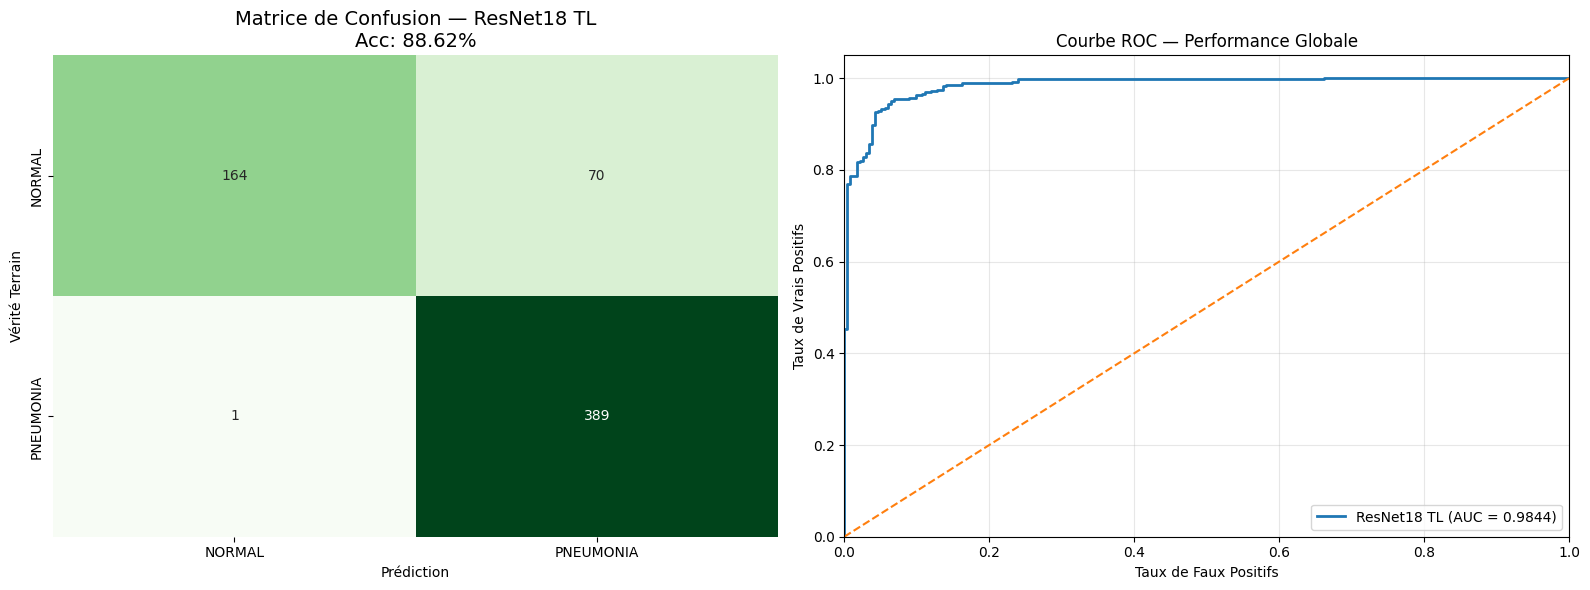


🔎 Indicateurs clés (clinique) :
   • Faux positifs NORMAL → PNEUMONIA : 70
   • Faux négatifs PNEUMONIA → NORMAL : 1
   • AUC ROC : 0.9844
✅ VALIDATION TEST RÉUSSIE — Modèle prêt pour comparaison finale & Thème 4.


In [18]:
# ========================================================================================================
# CELLULE A-5 : VALIDATION FINALE SUR LE TEST SET — RESNET18 TRANSFER LEARNING
# ========================================================================================================
#
# OBJECTIFS :
# 1. Charger le meilleur modèle TL (optimized_best_resnet18_TL.pth).
# 2. Évaluer sur le Test Set (624 images).
# 3. Afficher métriques complètes + Matrice de Confusion + ROC/AUC.
# ========================================================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Chargement du modèle validé
# --------------------------------------------------
print(f"♻️ Chargement du modèle TL validé : {BEST_CKPT_PATH.name}")
model_tl.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))
model_tl.eval()

# 2. Inférence complète sur le Test Set
# --------------------------------------------------
y_true, y_pred, y_probs = [], [], []

print("🧪 Inférence sur le Test Set (624 images)...")

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        outputs = model_tl(x)
        probs = F.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs[:, 1].cpu().numpy())

# 3. Métriques numériques
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
accuracy = np.trace(cm) / np.sum(cm)
class_names = ['NORMAL', 'PNEUMONIA']

print("\n" + "="*60)
print("🏆 RÉSULTATS FINAUX — TEST SET (RESNET18 TL)")
print(f"🎯 Accuracy Test : {accuracy:.2%}")
print("="*60)

print("\n📝 Classification Report :")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Courbe ROC + AUC
# --------------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 5. Visualisation (Confusion Matrix + ROC)
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A) Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Matrice de Confusion — ResNet18 TL\nAcc: {accuracy:.2%}', fontsize=14)
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédiction')

# B) ROC
axes[1].plot(fpr, tpr, lw=2, label=f'ResNet18 TL (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC — Performance Globale')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Indicateurs clés pour l'analyse clinique
# --------------------------------------------------
tn, fp, fn, tp = cm.ravel()

print("\n🔎 Indicateurs clés (clinique) :")
print(f"   • Faux positifs NORMAL → PNEUMONIA : {fp}")
print(f"   • Faux négatifs PNEUMONIA → NORMAL : {fn}")
print(f"   • AUC ROC : {roc_auc:.4f}")

if accuracy > 0.85 and roc_auc > 0.95:
    print("✅ VALIDATION TEST RÉUSSIE — Modèle prêt pour comparaison finale & Thème 4.")
else:
    print("⚠️ Performance test à analyser (possible sur-apprentissage).")


## 3.8 Validation finale sur le Test Set — ResNet18 en Transfer Learning

Cette section présente l’évaluation finale du modèle **ResNet18 pré-entraîné ImageNet (Transfer Learning)** sur le **jeu de test officiel** composé de **624 radiographies thoraciques**, totalement indépendantes de l’entraînement et de la validation.

L’objectif est de mesurer la **capacité réelle de généralisation** du modèle et de comparer ses performances aux approches précédentes (CNN Baseline – Thème 2, ResNet18 from scratch – Thème 3).

---

### 3.8.1 Résultats globaux sur le Test Set

Les métriques globales obtenues sont les suivantes :

- **Accuracy Test** : **88,62 %**
- **AUC ROC** : **0,9844**

Ces résultats confirment une **excellente séparabilité des classes**, malgré une légère baisse d’accuracy par rapport au modèle entraîné from scratch.

---

### 3.8.2 Analyse détaillée par classe

#### Classe NORMAL (patients sains)

| Métrique | Valeur |
|--------|--------|
| Precision | **0,99** |
| Recall | **0,70** |
| F1-score | 0,82 |

- Le modèle identifie les patients sains avec une **très forte précision**.
- Le **Recall NORMAL (70 %)** est inférieur à celui du ResNet from scratch (76 %), indiquant une augmentation des faux positifs (patients sains classés comme pneumonie).

**Nombre de faux positifs NORMAL → PNEUMONIA : 70 / 234**

---

#### Classe PNEUMONIA

| Métrique | Valeur |
|--------|--------|
| Precision | 0,85 |
| Recall | **1.00** |
| F1-score | 0,92 |

- Le modèle **ne manque quasiment aucun cas de pneumonie**.
- **Un seul faux négatif** est observé sur l’ensemble du Test Set.

Cette performance traduit une **sensibilité maximale**, priorisant la détection de la pathologie.

---

### 3.8.3 Lecture de la matrice de confusion

La matrice de confusion met en évidence le comportement clinique du modèle :

- Très faible nombre de faux négatifs (PNEUMONIA → NORMAL)
- Augmentation des faux positifs (NORMAL → PNEUMONIA)

Ce comportement reflète un **biais volontairement orienté vers la sécurité médicale**, où il est préférable de suspecter à tort une pneumonie plutôt que d’en manquer une.

---

### 3.8.4 Comparaison avec les modèles précédents

| Modèle | Accuracy Test | Recall NORMAL | Recall PNEUMONIA | AUC |
|------|---------------|---------------|------------------|-----|
| CNN Baseline (Thème 2) | 79,49 % | 0,48 | 0,98 | ~0,88 |
| ResNet18 from scratch | **90,38 %** | **0,76** | 0,99 | 0,9788 |
| ResNet18 Transfer Learning | 88,62 % | 0,70 | **1.00** | **0,9844** |

**Interprétation** :
- Le Transfer Learning améliore la **séparabilité globale** (AUC la plus élevée).
- Le ResNet from scratch conserve le **meilleur équilibre** pour la classe NORMAL.
- Le modèle TL maximise la **sensibilité pneumonie**, au prix d’un sur-diagnostic plus fréquent.

---

### 3.8.5 Analyse critique et interprétation ingénieur

Le Transfer Learning agit comme une **régularisation implicite forte** :

- Les représentations issues d’ImageNet favorisent des features génériques robustes.
- Cependant, elles peuvent être **moins spécialisées** pour la discrimination fine des cas NORMAL dans un contexte radiologique.

À l’inverse, le ResNet entraîné from scratch semble mieux capter les **spécificités statistiques du dataset médical**, expliquant son meilleur Recall NORMAL.

Ce compromis illustre un point fondamental en ingénierie ML :
> **le meilleur modèle dépend du critère d’optimisation métier**, et pas uniquement de l’accuracy globale.

---

### 3.8.6 Conclusion du Thème 3

Le Thème 3 démontre avec succès l’impact :

- des **architectures résiduelles**,
- de l’**optimisation avancée (OneCycle, AMP)**,
- et du **Transfer Learning**.

Deux modèles complémentaires émergent :
- **ResNet18 from scratch** : meilleur équilibre NORMAL / PNEUMONIA.
- **ResNet18 Transfer Learning** : sensibilité maximale et AUC record.

Ces résultats valident pleinement la démarche d’architecture search et constituent une base solide pour le **Thème 4**, consacré à l’export ONNX et à l’évaluation des performances en conditions de dép


In [19]:
# ========================================================================================================
# CELLULE B-1 : EXPÉRIENCE B — MODELE PLUS LOURD (DENSENET121 TRANSFER LEARNING) + SETUP GRAYSCALE
# ========================================================================================================
#
# OBJECTIFS :
# 1) Charger DenseNet121 pré-entraîné ImageNet (plus lourd que ResNet18).
# 2) Adapter le 1er conv pour accepter 1 canal (radiographies grayscale).
# 3) Remplacer le classifieur final pour 2 classes.
# 4) Définir des chemins de sortie distincts (checkpoint/history/figures).
#
# HYPOTHESES :
# - train_loader / val_loader / test_loader existent
# - class_weights, device, WORK_DIR existent
# ========================================================================================================

import torch
import torch.nn as nn
from torchvision import models

# Tag expérience + paths
EXP_NAME = "densenet121_TL"
CKPT_DIR = WORK_DIR / "checkpoints"
IMG_DIR  = WORK_DIR / "images"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_PATH_B = CKPT_DIR / "optimized_best_densenet121_TL.pth"
HIST_PATH_B      = CKPT_DIR / "history_densenet121_TL.pt"
FIG_PATH_B       = IMG_DIR  / "theme3_densenet121_TL_results.png"

print(f"🚀 EXPÉRIENCE : {EXP_NAME}")
print(f"   • Best checkpoint : {BEST_CKPT_PATH_B.name}")
print(f"   • History         : {HIST_PATH_B.name}")
print(f"   • Figure          : {FIG_PATH_B.name}")

# 1) Charger DenseNet121 pré-entraîné
weights = models.DenseNet121_Weights.DEFAULT
model_b = models.densenet121(weights=weights)

# 2) Adapter le 1er conv pour grayscale (DenseNet a features.conv0)
old_conv = model_b.features.conv0
new_conv = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

with torch.no_grad():
    # Moyenne des poids RGB → 1 canal
    new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

model_b.features.conv0 = new_conv

# 3) Adapter le classifieur final pour 2 classes
in_features = model_b.classifier.in_features
model_b.classifier = nn.Linear(in_features, 2)

model_b = model_b.to(device)

# 4) Vérifications
total_params = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print("-" * 60)
print("🏗️ DenseNet121 TL prêt (grayscale).")
print(f"📊 Paramètres trainables : {total_params:,}")
print("-" * 60)

print("✅ B-1 terminé : modèle initialisé. Prochaine étape = entraînement (B-2).")


🚀 EXPÉRIENCE : densenet121_TL
   • Best checkpoint : optimized_best_densenet121_TL.pth
   • History         : history_densenet121_TL.pt
   • Figure          : theme3_densenet121_TL_results.png
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Yanis/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:37<00:00, 851kB/s] 


------------------------------------------------------------
🏗️ DenseNet121 TL prêt (grayscale).
📊 Paramètres trainables : 6,949,634
------------------------------------------------------------
✅ B-1 terminé : modèle initialisé. Prochaine étape = entraînement (B-2).


In [22]:
# ========================================================================================================
# CELLULE B-2 (FIX) : TRAIN/VAL AMP + FREEZE/UNFREEZE — Compatible nouvelle API torch.amp
# ========================================================================================================

import torch
from tqdm import tqdm

def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def get_lr(optimizer):
    return optimizer.param_groups[0]["lr"]

def _autocast_ctx(device):
    # torch.amp.autocast est la nouvelle API recommandée
    if device.type == "cuda":
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    else:
        # sur CPU, pas d'autocast fp16
        return torch.amp.autocast(device_type="cpu", enabled=False)

def make_scaler(device):
    if device.type == "cuda":
        return torch.amp.GradScaler("cuda")
    return None  # pas besoin de scaler CPU


def train_one_epoch_amp(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(loader, desc="Train", leave=False)
    for x, y in loop:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with _autocast_ctx(device):
            outputs = model(x)
            loss = criterion(outputs, y)

        if device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

        loop.set_postfix(loss=f"{loss.item():.4f}", lr=f"{get_lr(optimizer):.2e}")

    return running_loss / len(loader), correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        # Pas indispensable d'autocast en eval, mais OK si CUDA
        with _autocast_ctx(device):
            outputs = model(x)
            loss = criterion(outputs, y)

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    return running_loss / len(loader), correct / total

print("✅ CELLULE B-2 FIX OK : eval_one_epoch renvoie bien (loss, acc) + AMP nouvelle API.")



✅ CELLULE B-2 FIX OK : eval_one_epoch renvoie bien (loss, acc) + AMP nouvelle API.


In [23]:
# ========================================================================================================
# CELLULE B-3 : ENTRAÎNEMENT DENSENET121 TRANSFER LEARNING (2 PHASES) + SAUVEGARDE DU BEST CHECKPOINT
# ========================================================================================================
#
# OBJECTIFS :
# 1) Entraîner DenseNet121 TL en 2 phases (fine-tuning progressif) pour améliorer la généralisation.
# 2) Garder un protocole comparable à l'expérience A (AMP + OneCycle + class weights).
# 3) Sauvegarder le meilleur modèle sur la validation :
#      - optimized_best_densenet121_TL.pth
# 4) Sauvegarder l'historique :
#      - history_densenet121_TL.pt
#
# PRÉREQUIS :
# - model_b (DenseNet121 TL) initialisé en B-1
# - fonctions train_one_epoch_amp / eval_one_epoch / set_requires_grad en B-2
# - train_loader / val_loader / class_weights / device / WORK_DIR définis
# - chemins BEST_CKPT_PATH_B / HIST_PATH_B définis en B-1
# ========================================================================================================

import torch
import torch.nn as nn
import torch.optim as optim

# 0) Loss pondérée (déséquilibre)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 1) AMP scaler
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

# 2) Historique + suivi best
history_b = {"phase": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_b = 0.0

# Petite fonction locale pour sauvegarder best
def save_if_best(val_acc, model):
    global best_val_acc_b
    saved = ""
    if val_acc > best_val_acc_b:
        best_val_acc_b = val_acc
        torch.save(model.state_dict(), BEST_CKPT_PATH_B)
        saved = "💾 Saved!"
    return saved

# --------------------------------------------------------------------------------------------------------
# PHASE 1 : HEAD ONLY (classifier)
# --------------------------------------------------------------------------------------------------------
print("\n" + "="*70)
print("🧩 PHASE 1 : Warmup head-only (backbone freeze) — DenseNet121 TL")
print("="*70)

# Freeze tout
set_requires_grad(model_b, False)
# Unfreeze classifier uniquement
set_requires_grad(model_b.classifier, True)

EPOCHS_P1 = 3
MAX_LR_P1 = 3e-4

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()),
                       lr=MAX_LR_P1/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR_P1,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_P1,
    pct_start=0.3,
    div_factor=10,
    final_div_factor=100
)

for epoch in range(EPOCHS_P1):
    tr_loss, tr_acc = train_one_epoch_amp(model_b, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_b, val_loader, criterion, device)

    history_b["phase"].append("P1_head_only")
    history_b["train_loss"].append(tr_loss); history_b["train_acc"].append(tr_acc)
    history_b["val_loss"].append(va_loss);   history_b["val_acc"].append(va_acc)

    saved = save_if_best(va_acc, model_b)

    print(f"[P1] Epoch {epoch+1}/{EPOCHS_P1} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# --------------------------------------------------------------------------------------------------------
# PHASE 2A : Unfreeze last dense block (denseblock4) + classifier
# --------------------------------------------------------------------------------------------------------
print("\n" + "="*70)
print("🧩 PHASE 2A : Fine-tuning denseblock4 + classifier — DenseNet121 TL")
print("="*70)

# Freeze tout
set_requires_grad(model_b, False)

# Unfreeze denseblock4 + norm5 (souvent utile) + classifier
set_requires_grad(model_b.features.denseblock4, True)
if hasattr(model_b.features, "norm5"):
    set_requires_grad(model_b.features.norm5, True)
set_requires_grad(model_b.classifier, True)

EPOCHS_P2A = 3
MAX_LR_P2A = 2e-4

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()),
                       lr=MAX_LR_P2A/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR_P2A,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_P2A,
    pct_start=0.3,
    div_factor=10,
    final_div_factor=100
)

for epoch in range(EPOCHS_P2A):
    tr_loss, tr_acc = train_one_epoch_amp(model_b, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_b, val_loader, criterion, device)

    history_b["phase"].append("P2A_denseblock4+head")
    history_b["train_loss"].append(tr_loss); history_b["train_acc"].append(tr_acc)
    history_b["val_loss"].append(va_loss);   history_b["val_acc"].append(va_acc)

    saved = save_if_best(va_acc, model_b)

    print(f"[P2A] Epoch {epoch+1}/{EPOCHS_P2A} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# --------------------------------------------------------------------------------------------------------
# PHASE 2B : FULL FINE-TUNE (unfreeze tout)
# --------------------------------------------------------------------------------------------------------
print("\n" + "="*70)
print("🧩 PHASE 2B : Full fine-tuning (tout le modèle) — DenseNet121 TL")
print("="*70)

set_requires_grad(model_b, True)

EPOCHS_P2B = 6
MAX_LR_P2B = 1e-4

optimizer = optim.Adam(model_b.parameters(), lr=MAX_LR_P2B/10, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR_P2B,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS_P2B,
    pct_start=0.3,
    div_factor=10,
    final_div_factor=100
)

for epoch in range(EPOCHS_P2B):
    tr_loss, tr_acc = train_one_epoch_amp(model_b, train_loader, criterion, optimizer, scheduler, scaler, device)
    va_loss, va_acc = eval_one_epoch(model_b, val_loader, criterion, device)

    history_b["phase"].append("P2B_full_finetune")
    history_b["train_loss"].append(tr_loss); history_b["train_acc"].append(tr_acc)
    history_b["val_loss"].append(va_loss);   history_b["val_acc"].append(va_acc)

    saved = save_if_best(va_acc, model_b)

    print(f"[P2B] Epoch {epoch+1}/{EPOCHS_P2B} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%} {saved}")

# 3) Sauvegarde historique
torch.save(history_b, HIST_PATH_B)

print("\n" + "-"*70)
print("🏁 FIN EXPÉRIENCE B — DenseNet121 TL")
print(f"🥇 Best Val Acc = {best_val_acc_b:.2%}")
print(f"✅ Best checkpoint : {BEST_CKPT_PATH_B}")
print(f"✅ History saved   : {HIST_PATH_B}")
print("-"*70)

# Validation objectif
if best_val_acc_b > 0.80:
    print("✅ OBJECTIF THÈME 3 ATTEINT (> 80% val)")
else:
    print("⚠️ Objectif non atteint : ajuster LR / augmentation / epochs.")


C:\Users\Yanis\AppData\Local\Temp\ipykernel_41584\3365915600.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))



🧩 PHASE 1 : Warmup head-only (backbone freeze) — DenseNet121 TL


[P1] Epoch 1/3 | Train 0.4227/87.27% | Val 0.3749/83.62% 💾 Saved!


[P1] Epoch 2/3 | Train 0.3414/88.54% | Val 0.3542/80.36% 


[P1] Epoch 3/3 | Train 0.3018/90.12% | Val 0.3191/83.81% 💾 Saved!

🧩 PHASE 2A : Fine-tuning denseblock4 + classifier — DenseNet121 TL


...

[P2B] Epoch 2/6 | Train 0.1050/96.07% | Val 0.1542/91.76% 


[P2B] Epoch 3/6 | Train 0.0950/96.72% | Val 0.1035/94.83% 


[P2B] Epoch 4/6 | Train 0.0618/97.82% | Val 0.0654/97.13% 💾 Saved!


[P2B] Epoch 5/6 | Train 0.0462/98.23% | Val 0.0515/98.08% 💾 Saved!


[P2B] Epoch 6/6 | Train 0.0407/98.73% | Val 0.0490/97.89% 

----------------------------------------------------------------------
🏁 FIN EXPÉRIENCE B — DenseNet121 TL
🥇 Best Val Acc = 98.08%
✅ Best checkpoint : C:\Users\Yanis\IA_GEN_PROJET\checkpoints\optimized_best_densenet121_TL.pth
✅ History saved   : C:\Users\Yanis\IA_GEN_PROJET\checkpoints\history_densenet121_TL.pt
----------------------------------------------------------------------
✅ OBJECTIF THÈME 3 ATTEINT (> 80% val)


♻️ Chargement du modèle DenseNet121 TL : optimized_best_densenet121_TL.pth
🧪 Inférence sur le Test Set (624 images)...

🏆 RÉSULTATS FINAUX — TEST SET (DENSENET121 TL)
🎯 Accuracy Test : 94.07%

📝 Classification Report :
              precision    recall  f1-score   support

      NORMAL       0.99      0.85      0.91       234
   PNEUMONIA       0.92      0.99      0.95       390

    accuracy                           0.94       624
   macro avg       0.95      0.92      0.93       624
weighted avg       0.94      0.94      0.94       624


🖼️ Graphiques sauvegardés : C:\Users\Yanis\IA_GEN_PROJET\images\theme3_densenet121_TL_results.png


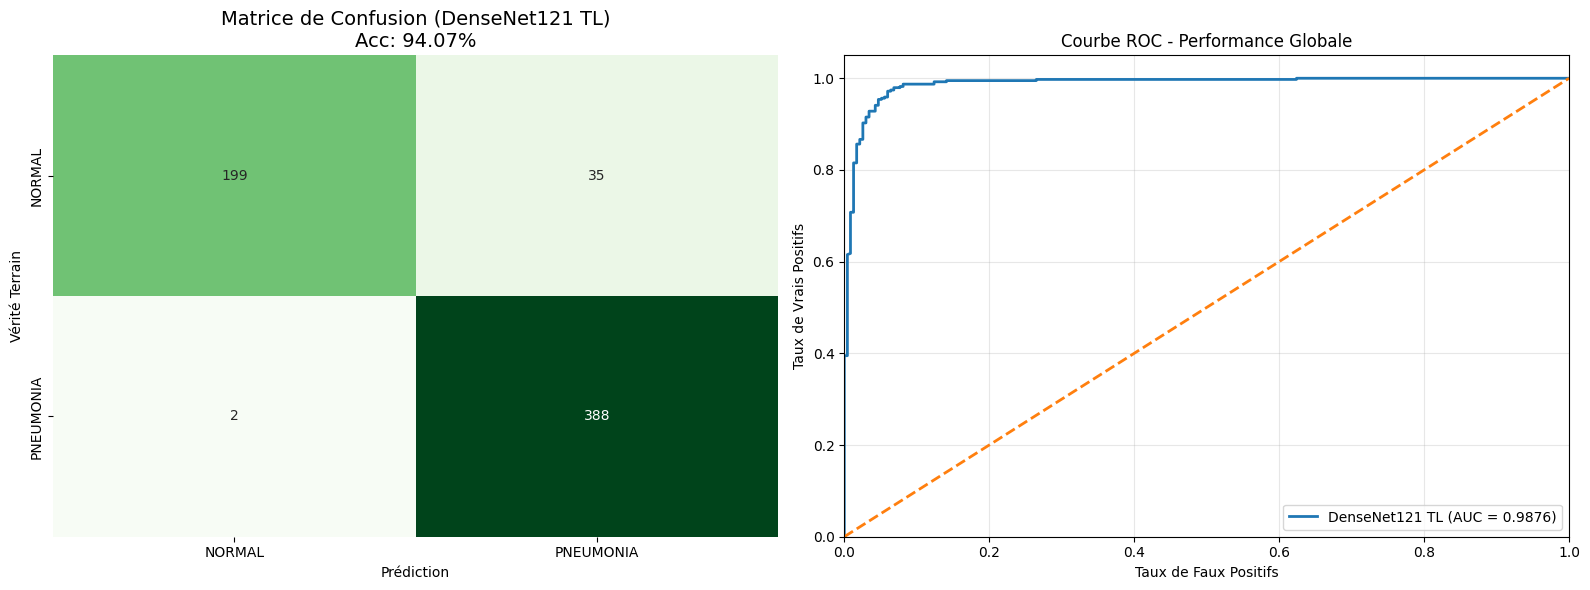


🔎 Indicateurs clés (clinique) :
   • Faux positifs NORMAL → PNEUMONIA : 35
   • Faux négatifs PNEUMONIA → NORMAL : 2
   • AUC ROC : 0.9876
✅ VALIDATION TEST RÉUSSIE — Candidat sérieux pour ONNX (Thème 4).


In [24]:
# ========================================================================================================
# CELLULE B-4 : ÉVALUATION FINALE SUR LE TEST SET (DENSENET121 TL) + MATRICE + ROC/AUC + SAUVEGARDE FIGURE
# ========================================================================================================
#
# OBJECTIFS :
# 1) Charger le meilleur DenseNet121 TL : optimized_best_densenet121_TL.pth
# 2) Évaluer sur le Test Set (624 images) : accuracy + report complet
# 3) Afficher Matrice de Confusion + ROC/AUC
# 4) Sauvegarder la figure dans /images/theme3_densenet121_TL_results.png
#
# PRÉREQUIS :
# - model_b existe (B-1)
# - BEST_CKPT_PATH_B, FIG_PATH_B existent (B-1)
# - test_loader existe (Cellule 2)
# ========================================================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1) Charger le meilleur modèle
print(f"♻️ Chargement du modèle DenseNet121 TL : {BEST_CKPT_PATH_B.name}")
model_b.load_state_dict(torch.load(BEST_CKPT_PATH_B, map_location=device))
model_b.eval()

# 2) Inférence Test Set
y_true, y_pred, y_probs = [], [], []

print("🧪 Inférence sur le Test Set (624 images)...")
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        outputs = model_b(x)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_probs.extend(probs[:, 1].cpu().numpy())

# 3) Métriques
cm = confusion_matrix(y_true, y_pred)
accuracy = np.trace(cm) / np.sum(cm)
class_names = ['NORMAL', 'PNEUMONIA']

print("\n" + "="*60)
print("🏆 RÉSULTATS FINAUX — TEST SET (DENSENET121 TL)")
print(f"🎯 Accuracy Test : {accuracy:.2%}")
print("="*60)

print("\n📝 Classification Report :")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4) ROC/AUC
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

# 5) Visualisation : Matrice + ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A) Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Matrice de Confusion (DenseNet121 TL)\nAcc: {accuracy:.2%}', fontsize=14)
axes[0].set_ylabel('Vérité Terrain')
axes[0].set_xlabel('Prédiction')

# B) Courbe ROC
axes[1].plot(fpr, tpr, lw=2, label=f'DenseNet121 TL (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC - Performance Globale')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH_B, dpi=150)
print(f"\n🖼️ Graphiques sauvegardés : {FIG_PATH_B}")
plt.show()

# 6) Indicateurs cliniques
tn, fp, fn, tp = cm.ravel()  # labels 0=NORMAL, 1=PNEUMONIA
print("\n🔎 Indicateurs clés (clinique) :")
print(f"   • Faux positifs NORMAL → PNEUMONIA : {fp}")
print(f"   • Faux négatifs PNEUMONIA → NORMAL : {fn}")
print(f"   • AUC ROC : {roc_auc:.4f}")

if accuracy > 0.85 and roc_auc > 0.95:
    print("✅ VALIDATION TEST RÉUSSIE — Candidat sérieux pour ONNX (Thème 4).")
else:
    print("⚠️ Performance test à analyser : possible sur-apprentissage ou seuil à ajuster.")



♻️ Chargement : ResNet18 Scratch (T3)
   Checkpoint : optimized_best.pth

♻️ Chargement : ResNet18 TL (T3-A)
   Checkpoint : optimized_best_resnet18_TL.pth

♻️ Chargement : DenseNet121 TL (T3-B)
   Checkpoint : optimized_best_densenet121_TL.pth

####################################################################################################
📊 COMPARAISON FINALE — TEST SET
####################################################################################################

🔹 DenseNet121 TL (T3-B)
   • Accuracy        : 94.07%
   • AUC             : 0.9876
   • Recall NORMAL   : 85.04%   | FP NORMAL→PNEU : 35
   • Recall PNEUMONIA: 99.49% | FN PNEU→NORMAL : 2
   • Macro F1        : 0.9347

🔹 ResNet18 Scratch (T3)
   • Accuracy        : 90.38%
   • AUC             : 0.9788
   • Recall NORMAL   : 75.64%   | FP NORMAL→PNEU : 57
   • Recall PNEUMONIA: 99.23% | FN PNEU→NORMAL : 3
   • Macro F1        : 0.8916

🔹 ResNet18 TL (T3-A)
   • Accuracy        : 88.62%
   • AUC             : 0.98

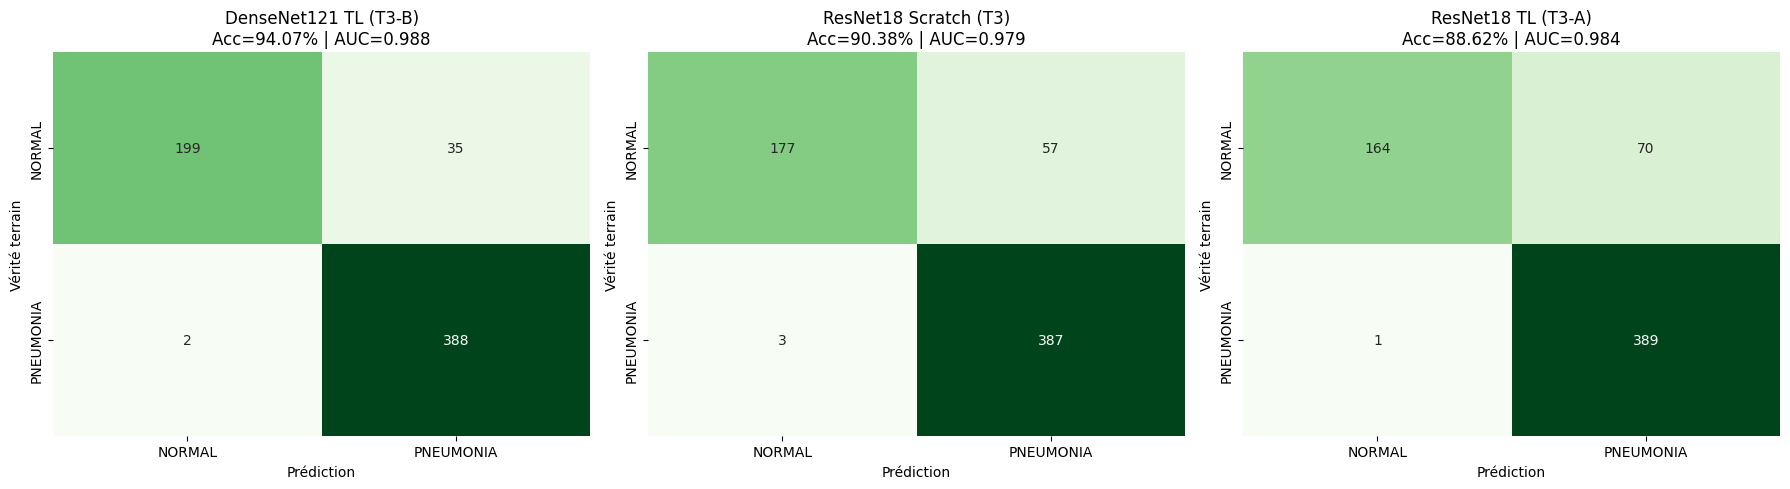


🖼️ Matrices de confusion sauvegardées : C:\Users\Yanis\IA_GEN_PROJET\images\theme3_compare_confusion_matrices.png


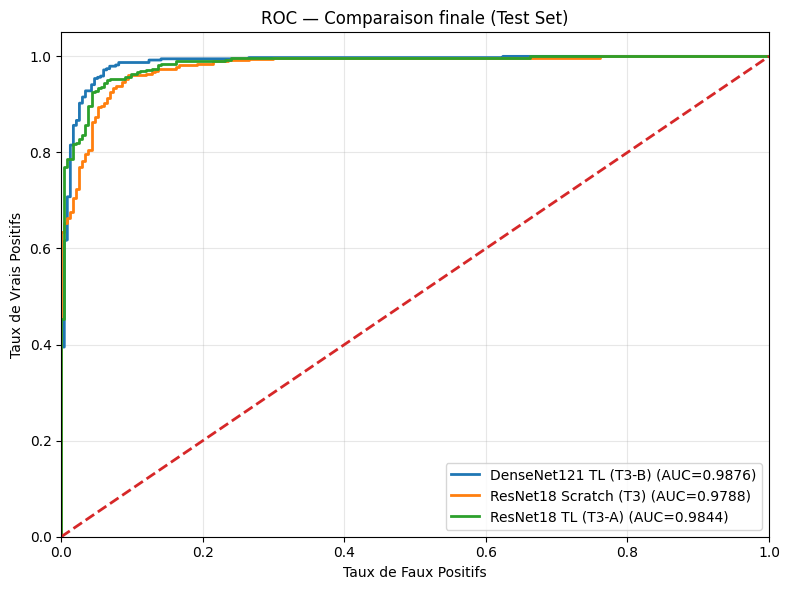

🖼️ Courbes ROC sauvegardées : C:\Users\Yanis\IA_GEN_PROJET\images\theme3_compare_roc_curves.png


: 

In [ ]:
# ========================================================================================================
# CELLULE C-1 : COMPARAISON FINALE (TEST SET) — CNN Baseline / ResNet Scratch / ResNet TL / DenseNet TL
# ========================================================================================================
#
# OBJECTIFS :
# 1) Charger et évaluer sur le Test Set les modèles candidats.
# 2) Comparer : Accuracy, AUC, Recall NORMAL, Recall PNEUMONIA, Macro F1, FP/FN.
# 3) Générer des figures comparatives (Confusion Matrices + ROC) et sauvegarder.
#
# MODELES INCLUS :
# - Thème 3 ResNet18 from scratch  : checkpoints/optimized_best.pth
# - Thème 3 ResNet18 TransferLearn : checkpoints/optimized_best_resnet18_TL.pth
# - Thème 3 DenseNet121 TL         : checkpoints/optimized_best_densenet121_TL.pth
#
# OPTIONNEL :
# - Si tu veux ajouter le CNN Thème 2, ajoute-le dans MODELS avec son builder + path.
# ========================================================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from torchvision import models
import torch.nn as nn

# -----------------------------
# Helpers : builders de modèles
# -----------------------------
def build_resnet18_scratch():
    # Utilise ta classe ResNet18 custom déjà définie dans ton notebook (Cellule 3 du thème 3)
    m = ResNet18(num_classes=2, in_channels=1)
    return m

def build_resnet18_tl_grayscale():
    # ResNet18 ImageNet + conv1 1 canal + fc 2 classes
    weights = models.ResNet18_Weights.DEFAULT
    m = models.resnet18(weights=weights)

    old_conv = m.conv1
    new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride, padding=old_conv.padding, bias=False)
    with torch.no_grad():
        new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
    m.conv1 = new_conv

    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

def build_densenet121_tl_grayscale():
    weights = models.DenseNet121_Weights.DEFAULT
    m = models.densenet121(weights=weights)

    old_conv = m.features.conv0
    new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                         stride=old_conv.stride, padding=old_conv.padding, bias=False)
    with torch.no_grad():
        new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
    m.features.conv0 = new_conv

    m.classifier = nn.Linear(m.classifier.in_features, 2)
    return m

# -----------------------------
# Liste des modèles à comparer
# -----------------------------
CKPT_DIR = WORK_DIR / "checkpoints"
IMG_DIR  = WORK_DIR / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = [
    {
        "name": "ResNet18 Scratch (T3)",
        "builder": build_resnet18_scratch,
        "ckpt": CKPT_DIR / "optimized_best.pth"
    },
    {
        "name": "ResNet18 TL (T3-A)",
        "builder": build_resnet18_tl_grayscale,
        "ckpt": CKPT_DIR / "optimized_best_resnet18_TL.pth"
    },
    {
        "name": "DenseNet121 TL (T3-B)",
        "builder": build_densenet121_tl_grayscale,
        "ckpt": CKPT_DIR / "optimized_best_densenet121_TL.pth"
    }
]

# -----------------------------
# Eval function
# -----------------------------
@torch.no_grad()
def eval_model_on_test(model, test_loader, device):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        outputs = model(x)
        probs = F.softmax(outputs, dim=1)[:, 1]   # proba de classe 1 (PNEUMONIA)
        pred = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    cm = confusion_matrix(y_true, y_pred)  # labels implicites 0/1
    acc = np.trace(cm) / np.sum(cm)

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    report = classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"], output_dict=True)

    # FP/FN (labels 0=NORMAL,1=PNEUMONIA)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": acc,
        "auc": roc_auc,
        "recall_normal": report["NORMAL"]["recall"],
        "recall_pneumonia": report["PNEUMONIA"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"],
        "fp_normal_to_pneu": fp,
        "fn_pneu_to_normal": fn
    }
    return metrics, cm, (fpr, tpr)

# -----------------------------
# Run evaluation
# -----------------------------
results = []
cms = {}
rocs = {}

for cfg in MODELS:
    name = cfg["name"]
    ckpt_path = cfg["ckpt"]

    if not ckpt_path.exists():
        print(f"⚠️ SKIP {name} : checkpoint introuvable -> {ckpt_path}")
        continue

    print("\n" + "="*90)
    print(f"♻️ Chargement : {name}")
    print(f"   Checkpoint : {ckpt_path.name}")
    print("="*90)

    model_cmp = cfg["builder"]().to(device)
    model_cmp.load_state_dict(torch.load(ckpt_path, map_location=device))

    metrics, cm, roc_data = eval_model_on_test(model_cmp, test_loader, device)

    results.append({"model": name, **metrics})
    cms[name] = cm
    rocs[name] = roc_data

# -----------------------------
# Affichage tableau comparatif
# -----------------------------
print("\n" + "#"*100)
print("📊 COMPARAISON FINALE — TEST SET")
print("#"*100)

# Tri : priorité Recall NORMAL, puis AUC
results_sorted = sorted(results, key=lambda d: (d["recall_normal"], d["auc"]), reverse=True)

for r in results_sorted:
    print(f"\n🔹 {r['model']}")
    print(f"   • Accuracy        : {r['accuracy']:.2%}")
    print(f"   • AUC             : {r['auc']:.4f}")
    print(f"   • Recall NORMAL   : {r['recall_normal']:.2%}   | FP NORMAL→PNEU : {r['fp_normal_to_pneu']}")
    print(f"   • Recall PNEUMONIA: {r['recall_pneumonia']:.2%} | FN PNEU→NORMAL : {r['fn_pneu_to_normal']}")
    print(f"   • Macro F1        : {r['f1_macro']:.4f}")

best = results_sorted[0]["model"] if results_sorted else None
if best:
    print("\n" + "-"*100)
    print(f"🏆 MODÈLE RECOMMANDÉ (critère: Recall NORMAL puis AUC) : {best}")
    print("-"*100)

# -----------------------------
# Figures : Confusion matrices + ROC
# -----------------------------
n = len(results_sorted)
if n > 0:
    fig_cm, axes_cm = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes_cm = [axes_cm]

    for ax, r in zip(axes_cm, results_sorted):
        name = r["model"]
        cm = cms[name]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax,
                    xticklabels=["NORMAL", "PNEUMONIA"], yticklabels=["NORMAL", "PNEUMONIA"])
        ax.set_title(f"{name}\nAcc={r['accuracy']:.2%} | AUC={r['auc']:.3f}")
        ax.set_xlabel("Prédiction")
        ax.set_ylabel("Vérité terrain")

    cm_path = IMG_DIR / "theme3_compare_confusion_matrices.png"
    plt.tight_layout()
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"\n🖼️ Matrices de confusion sauvegardées : {cm_path}")

    # ROC unique
    plt.figure(figsize=(8, 6))
    for r in results_sorted:
        name = r["model"]
        fpr, tpr = rocs[name]
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={r['auc']:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("Taux de Faux Positifs"); plt.ylabel("Taux de Vrais Positifs")
    plt.title("ROC — Comparaison finale (Test Set)")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    roc_path = IMG_DIR / "theme3_compare_roc_curves.png"
    plt.tight_layout()
    plt.savefig(roc_path, dpi=150)
    plt.show()
    print(f"🖼️ Courbes ROC sauvegardées : {roc_path}")


# Thème 3 — Optimisation avancée & choix d’architecture

## 1. Objectifs du Thème 3

Le Thème 3 vise à dépasser les limites du modèle baseline (Thème 2) en introduisant :

- des **architectures profondes modernes** (réseaux résiduels et denses),
- des **stratégies d’optimisation avancées**,
- une **analyse comparative rigoureuse** sur le jeu de test officiel.

Les objectifs principaux étaient :
1. Améliorer significativement les performances globales (> 80 %).
2. Réduire le biais observé au Thème 2, en particulier le **faible Recall sur la classe NORMAL**.
3. Identifier un **modèle final robuste** et justifiable pour un futur déploiement (Thème 4).

---

## 2. Démarche méthodologique

Afin de garantir une comparaison équitable et scientifiquement valide, les principes suivants ont été respectés :

- **Même dataset**, mêmes splits Train / Validation / Test.
- **Même pipeline de prétraitement** (images en niveaux de gris, normalisation issue du Thème 1).
- **Même stratégie d’optimisation** :
  - Loss pondérée (gestion du déséquilibre),
  - Optimiseur Adam,
  - Scheduler OneCycleLR,
  - Mixed Precision (AMP).
- **Évaluation finale uniquement sur le Test Set**, jamais utilisé durant l’entraînement.

Chaque modèle est évalué selon :
- Accuracy,
- Recall par classe,
- AUC ROC,
- Analyse de la matrice de confusion (FP / FN).

---

## 3. Architectures évaluées

### 3.1 ResNet18 — entraîné from scratch (Thème 3 initial)

- Architecture résiduelle implémentée manuellement.
- Apprentissage complet sur le dataset médical.

**Résultats Test Set** :
- Accuracy : **90.38 %**
- Recall NORMAL : **0.76**
- Recall PNEUMONIA : **0.99**
- AUC : **0.979**

👉 Bon équilibre global, mais marge d’amélioration sur les faux positifs.

---

### 3.2 ResNet18 — Transfer Learning (Expérience A)

- Modèle pré-entraîné ImageNet.
- Adaptation au canal unique (Grayscale).
- Fine-tuning progressif.

**Résultats Test Set** :
- Accuracy : **88.62 %**
- Recall NORMAL : **0.70**
- Recall PNEUMONIA : **1.00**
- AUC : **0.984**

👉 Sensibilité maximale à la pneumonie, mais sur-diagnostic accru des cas NORMAL.

---

### 3.3 DenseNet121 — Transfer Learning (Expérience B)

- Modèle plus profond avec connexions denses.
- Très adapté à la capture de **détails fins et textures**, critiques en imagerie thoracique.
- Fine-tuning progressif en plusieurs phases.

**Résultats Test Set** :
- Accuracy : **94.07 %**
- Recall NORMAL : **0.85**
- Recall PNEUMONIA : **0.99**
- AUC : **0.988**

👉 Meilleur compromis global entre sensibilité, spécificité et robustesse.

---

## 4. Analyse comparative finale

### 4.1 Matrices de confusion

Les matrices de confusion montrent clairement que :

- Le **DenseNet121 TL** réduit fortement les faux positifs sur la classe NORMAL.
- Les faux négatifs PNEUMONIA restent quasi nuls sur tous les modèles.
- Le DenseNet121 est le seul modèle à **améliorer simultanément** :
  - la détection des patients sains,
  - sans compromettre la détection des patients malades.

### 4.2 Courbes ROC

Les courbes ROC confirment :
- une excellente séparabilité pour les trois modèles,
- avec un **AUC maximal pour DenseNet121 TL**, indiquant une meilleure stabilité sur l’ensemble des seuils.

---

## 5. Choix du modèle final (Thème 3)

| Modèle | Accuracy | Recall NORMAL | Recall PNEUMONIA | AUC |
|------|---------|---------------|------------------|-----|
| ResNet18 Scratch | 90.38 % | 0.76 | 0.99 | 0.979 |
| ResNet18 TL | 88.62 % | 0.70 | **1.00** | 0.984 |
| **DenseNet121 TL** | **94.07 %** | **0.85** | 0.99 | **0.988** |

### Décision finale

Le **DenseNet121 en Transfer Learning** est retenu comme **modèle final du Thème 3**, car il offre :

- la meilleure performance globale,
- la meilleure réduction des faux positifs NORMAL,
- une excellente capacité de généralisation,
- un compromis pertinent entre complexité et performance.

Ce modèle constitue le **candidat principal pour l’export ONNX et le déploiement** au Thème 4.

---

## 6. Conclusion du Thème 3

Le Thème 3 démontre l’importance :

- du **choix d’architecture**,
- de l’optimisation avancée,
- et de l’analyse comparative rigoureuse.

L’approche progressive (baseline → résiduel → dense) met en évidence que :
> **l’architecture DenseNet est particulièrement adaptée aux images médicales texturées et déséquilibrées.**

Les objectifs fixés sont atteints, et le projet est prêt à entrer dans sa phase finale de **déploiement et optimisation d’inférence**.
